In [10]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [11]:
class AgentState(TypedDict):
    number1: int
    number2: int
    operation1: str
    final_result1: int
    number3: int
    number4: int
    operation2: str
    final_result2: int

In [12]:
def adder_node_1(state: AgentState) -> AgentState:
    """This node adds two numbers and returns the result."""
    state["final_result1"] = state["number1"] + state["number2"]
    return state

In [13]:
def substractor_node_1(state: AgentState) -> AgentState:
    """This node substract two numbers and returns the result."""
    state["final_result1"] = state["number1"] - state["number2"]
    return state

In [14]:
def decider_node_1(state: AgentState) -> str:
    """This node decides which operation to perform based on the 'operation' key in the state."""
    if state["operation1"] == "+":
        return "add"
    elif state["operation1"] == "-":
        return "subtract"
    else:
        raise ValueError("Invalid operation. Use '+' or '-'.")

In [15]:
def adder_node_2(state: AgentState) -> AgentState:
    """This node adds two numbers and returns the result."""
    state["final_result2"] = state["number3"] + state["number4"]
    return state

In [16]:
def substractor_node_2(state: AgentState) -> AgentState:
    """This node substract two numbers and returns the result."""
    state["final_result2"] = state["number3"] - state["number4"]
    return state

In [17]:
def decider_node_2(state: AgentState) -> str:
    """This node decides which operation to perform based on the 'operation' key in the state."""
    if state["operation2"] == "+":
        return "add"
    elif state["operation2"] == "-":
        return "subtract"
    else:
        raise ValueError("Invalid operation. Use '+' or '-'.")

In [18]:
graph = StateGraph(AgentState)

graph.add_node("adder1", adder_node_1)
graph.add_node("substractor1", substractor_node_1)
graph.add_node("decider1", lambda state:state)

graph.add_edge(START, "decider1")
graph.add_conditional_edges(
    "decider1", 
    decider_node_1,
    {   #Edge : Node that we use creating the graph
        "add": "adder1",
        "subtract": "substractor1"
    }
)
graph.add_edge("adder1", "decider2")
graph.add_edge("substractor1", "decider2")

graph.add_node("adder2", adder_node_2)
graph.add_node("substractor2", substractor_node_2)
graph.add_node("decider2", lambda state:state)

graph.add_conditional_edges(
    "decider2", 
    decider_node_2,
    {   #Edge : Node that we use creating the graph
        "add": "adder2",
        "subtract": "substractor2"
    }
)
graph.add_edge("adder2", END)
graph.add_edge("substractor2", END)

app =graph.compile()

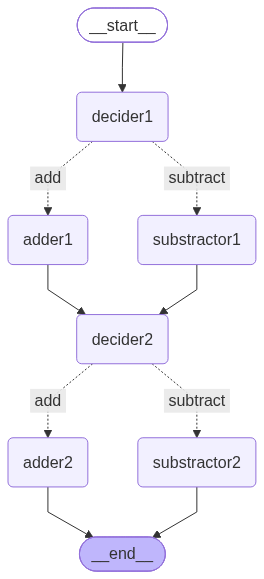

In [19]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))